In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from warpSPHCore import radiusSearchCompactHashMap, sphOperation_warp
from warpSPHCore.enumTypes import *

import matplotlib.pyplot as plt
from demo_util import *
from warpSPHPlotting import *

Warp 1.11.1 initialized:
   CUDA driver not found or failed to initialize
   Devices:
     "cpu"      : "aarch64"
   Kernel cache:
     /home/frieren/.cache/warp/1.11.1


Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. Proceeding in CPU-only mode.


In [2]:
device = torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [3]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Computing grid support with mode: 4 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.0623, 0.0623, 0.0623,  ..., 0.0623, 0.0623, 0.0623])
SupportsY: tensor([0.0623, 0.0623, 0.0623,  ..., 0.0623, 0.0623, 0.0623])
Module warpSPHCore.radiusSearch.wp_compactHash 4845d5a load on device 'cpu' took 0.95 ms  (cached)
Computing grid support with mode: 4 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.0623, 0.0623, 0.0623,  ..., 0.0623, 0.0623, 0.0623])
SupportsY: tensor([0.0623, 0.0623, 0.0623,  ..., 0.0623, 0.0623, 0.0623])
Module warpSPHCore.operations.wp_density 14892f2 load on device 'cpu' took 0.29 ms  (cached)
Module warpSPHCore.crk.crk_volume cb121df load on device 'cpu' took 0.29 ms  (cached)
Module warpSPHCore.crk.crk_moments a970da5 load on device 'cpu' took 0.25 ms  (cached)
Module warpSPHCore.crk.crk_density 9eed5d7 load on device 'cpu' took 0.30 ms  (cached)


In [17]:

# Map particle quantities to a grid using SPH-like interpolation
device = particleState.positions.device
dtype = particleState.positions.dtype

grid, dx, nxs, gridArea, gridExtent = generateGrid(domain, nx, device=device, dtype=dtype, alignment='center')

h = volumeToSupport(gridArea, 50, particleState.positions.shape[1])

gridStateA = ParticleState(
    positions = grid,
    supports = torch.full((grid.shape[0],), h, device=device, dtype=dtype)*2,
    masses = torch.full((grid.shape[0],), gridArea, device=device, dtype=dtype), 
    densities = torch.ones((grid.shape[0],), device=device, dtype=dtype),
    kinds = torch.full((grid.shape[0],), ParticleType.Fluid.value, device=device, dtype=torch.int32)
)
gridStateB = ParticleState(
    positions = grid,
    supports = torch.full((grid.shape[0],), h, device=device, dtype=dtype)*0,
    masses = torch.full((grid.shape[0],), gridArea, device=device, dtype=dtype), 
    densities = torch.ones((grid.shape[0],), device=device, dtype=dtype),
    kinds = torch.full((grid.shape[0],), ParticleType.Fluid.value, device=device, dtype=torch.int32)
)

In [18]:
adjacencyGather, hashMap = radiusSearchCompactHashMap(
    queryParticles=gridStateA,
    domain = domain,
    mode = SupportScheme.Gather,
    referenceParticles=gridStateB,
    returnCompactHashMap=True
)

print(f"Gather:")
print("Grid particles: {}, max neighbors: {}".format(gridStateA.positions.shape[0], adjacencyGather.numNeighbors.max().item()))
print(f'Total neighbors: {adjacencyGather.numNeighbors.sum().item()}')
print(f'ij shapes: {adjacencyGather.i.shape}/{adjacencyGather.j.shape}')

print(f'SupportA: {gridStateA.supports.min().item()}, supportB: {gridStateB.supports.min().item()}')
print(f'HashMap: {hashMap.hashTable.shape}, {hashMap.sortedCellTable.shape}')
print(f'HashMap Extent: {hashMap.qMin}, {hashMap.qMax}, h = {hashMap.hCell}')
print(f'HashMap numCells: {hashMap.numCells}, mode_uint: {hashMap.mode_uint}')

Computing grid support with mode: 1 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Computing grid support with mode: 1 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Gather:
Grid particles: 16384, max neighbors: 193
Total neighbors: 3162112
ij shapes: torch.Size([3162112])/torch.Size([3162112])
SupportA: 0.12466946244239807, supportB: 0.0
HashMap: torch.Size([16411, 2]), torch.Size([256, 3])
HashMap Extent: tensor([-1., -1.]), tensor([1., 1.]), h = 0.125
HashMap numCells: tensor([16, 16], dtype=torch.int32), mode_uint: 1


In [19]:
adjacencyScatter, hashMap = radiusSearchCompactHashMap(
    queryParticles=gridStateA,
    domain = domain,
    mode = SupportScheme.Scatter,
    referenceParticles=gridStateB,
    returnCompactHashMap=True
)

print(f"Scatter:")
print("Grid particles: {}, max neighbors: {}".format(gridStateA.positions.shape[0], adjacencyScatter.numNeighbors.max().item()))
print(f'Total neighbors: {adjacencyScatter.numNeighbors.sum().item()}')
print(f'ij shapes: {adjacencyScatter.i.shape}/{adjacencyScatter.j.shape}')

print(f'SupportA: {gridStateA.supports.min().item()}, supportB: {gridStateB.supports.min().item()}')
print(f'HashMap: {hashMap.hashTable.shape}, {hashMap.sortedCellTable.shape}')
print(f'HashMap Extent: {hashMap.qMin}, {hashMap.qMax}, h = {hashMap.hCell}')
print(f'HashMap numCells: {hashMap.numCells}, mode_uint: {hashMap.mode_uint}')

Computing grid support with mode: 2 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Computing grid support with mode: 2 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Scatter:
Grid particles: 16384, max neighbors: 1
Total neighbors: 16384
ij shapes: torch.Size([16384])/torch.Size([16384])
SupportA: 0.12466946244239807, supportB: 0.0
HashMap: torch.Size([16411, 2]), torch.Size([1, 3])
HashMap Extent: tensor([-1., -1.]), tensor([1., 1.]), h = 0.0
HashMap numCells: tensor([2147483647, 2147483647], dtype=torch.int32), mode_uint: 2


In [20]:
adjacencySymmetric, hashMap = radiusSearchCompactHashMap(
    queryParticles=gridStateA,
    domain = domain,
    mode = SupportScheme.Symmetric,
    referenceParticles=gridStateB,
    returnCompactHashMap=True
)

print(f"Symmetric:")
print("Grid particles: {}, max neighbors: {}".format(gridStateA.positions.shape[0], adjacencySymmetric.numNeighbors.max().item()))
print(f'Total neighbors: {adjacencySymmetric.numNeighbors.sum().item()}')
print(f'ij shapes: {adjacencySymmetric.i.shape}/{adjacencySymmetric.j.shape}')

print(f'SupportA: {gridStateA.supports.min().item()}, supportB: {gridStateB.supports.min().item()}')
print(f'HashMap: {hashMap.hashTable.shape}, {hashMap.sortedCellTable.shape}')
print(f'HashMap Extent: {hashMap.qMin}, {hashMap.qMax}, h = {hashMap.hCell}')
print(f'HashMap numCells: {hashMap.numCells}, mode_uint: {hashMap.mode_uint}')

Computing grid support with mode: 3 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Computing grid support with mode: 3 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Symmetric:
Grid particles: 16384, max neighbors: 45
Total neighbors: 737280
ij shapes: torch.Size([737280])/torch.Size([737280])
SupportA: 0.12466946244239807, supportB: 0.0
HashMap: torch.Size([16411, 2]), torch.Size([256, 3])
HashMap Extent: tensor([-1., -1.]), tensor([1., 1.]), h = 0.125
HashMap numCells: tensor([16, 16], dtype=torch.int32), mode_uint: 3


In [21]:
adjacencySuperSymmetric, hashMap = radiusSearchCompactHashMap(
    queryParticles=gridStateA,
    domain = domain,
    mode = SupportScheme.SuperSymmetric,
    referenceParticles=gridStateB,
    returnCompactHashMap=True
)
print(f"Super Symmetric:")
print("Grid particles: {}, max neighbors: {}".format(gridStateA.positions.shape[0], adjacencySuperSymmetric.numNeighbors.max().item()))
print(f'Total neighbors: {adjacencySuperSymmetric.numNeighbors.sum().item()}')
print(f'ij shapes: {adjacencySuperSymmetric.i.shape}/{adjacencySuperSymmetric.j.shape}')

print(f'SupportA: {gridStateA.supports.min().item()}, supportB: {gridStateB.supports.min().item()}')
print(f'HashMap: {hashMap.hashTable.shape}, {hashMap.sortedCellTable.shape}')
print(f'HashMap Extent: {hashMap.qMin}, {hashMap.qMax}, h = {hashMap.hCell}')
print(f'HashMap numCells: {hashMap.numCells}, mode_uint: {hashMap.mode_uint}')

Computing grid support with mode: 4 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Computing grid support with mode: 4 where 1=gather, 2=scatter, 3=symmetric, 4=superSymmetric
SupportsX: tensor([0.1247, 0.1247, 0.1247,  ..., 0.1247, 0.1247, 0.1247])
SupportsY: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Super Symmetric:
Grid particles: 16384, max neighbors: 193
Total neighbors: 3162112
ij shapes: torch.Size([3162112])/torch.Size([3162112])
SupportA: 0.12466946244239807, supportB: 0.0
HashMap: torch.Size([16411, 2]), torch.Size([256, 3])
HashMap Extent: tensor([-1., -1.]), tensor([1., 1.]), h = 0.125
HashMap numCells: tensor([16, 16], dtype=torch.int32), mode_uint: 4


In [22]:
print(f'Gather == SuperSymmetric: {adjacencyGather.i.shape == adjacencySuperSymmetric.i.shape and torch.all(adjacencyGather.i == adjacencySuperSymmetric.i)}, {adjacencyGather.j.shape == adjacencySuperSymmetric.j.shape and torch.all(adjacencyGather.j == adjacencySuperSymmetric.j)}')
print(f'Scatter == SuperSymmetric: {adjacencyScatter.i.shape == adjacencySuperSymmetric.i.shape and torch.all(adjacencyScatter.i == adjacencySuperSymmetric.i)}, {adjacencyScatter.j.shape == adjacencySuperSymmetric.j.shape and torch.all(adjacencyScatter.j == adjacencySuperSymmetric.j)}')

print(f'Gather == Symmetric: {adjacencyGather.i.shape == adjacencySymmetric.i.shape and torch.all(adjacencyGather.i == adjacencySymmetric.i)}, {adjacencyGather.j.shape == adjacencySymmetric.j.shape and torch.all(adjacencyGather.j == adjacencySymmetric.j)}')

Gather == SuperSymmetric: True, True
Scatter == SuperSymmetric: False, False
Gather == Symmetric: False, False


Module warpSPHCore.operations.wp_gradient 13b43b0 load on device 'cpu' took 2171.03 ms  (compiled)
Linear Gradient (WarpSPH):  tensor([[-2.0557e+02,  1.2202e+00],
        [-9.3934e+01,  5.9840e-01],
        [-4.5745e+00, -1.5501e-01],
        ...,
        [-1.0072e+01,  8.1801e-01],
        [-9.6639e+01,  3.5507e+00],
        [-2.2634e+02,  3.7371e+00]])
Mean Absolute Error in X Gradient:  5.071043014526367
Mean Absolute Error in Y Gradient:  0.19400642812252045


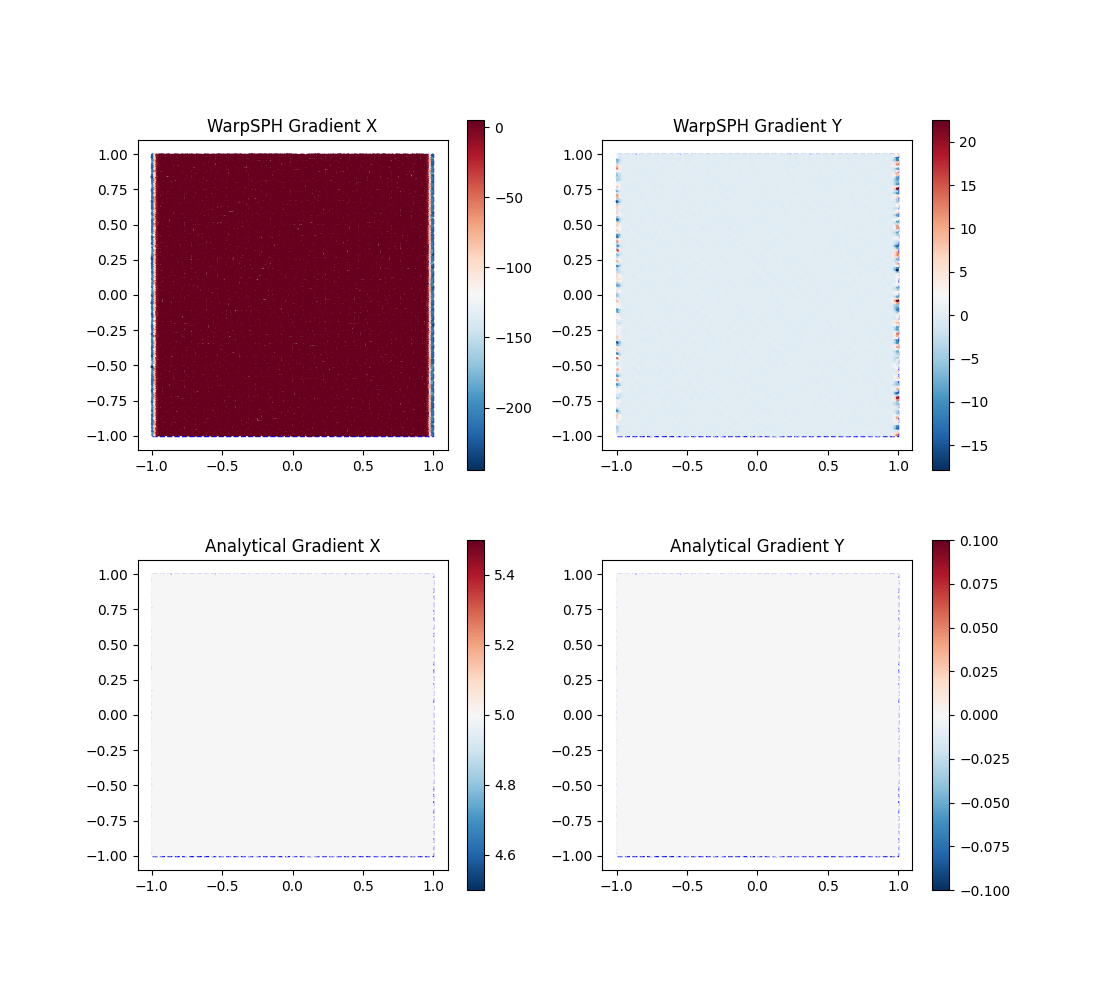

In [4]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = markerSize,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# as the visualize function accepts kwargs we can predefine common plotting settings in a PlottingOptions dataclass and then unpack it when calling the function to keep the code cleaner and more organized, especially when we have multiple visualizations that share the same settings. This way we can easily modify the common settings in one place without having to change each individual visualization call.
# For this case we explicitly extract the gradient components before calling the visualize function
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = linear_gradient_warp[:,0], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient X");
visualizeParticlesNew(fig, axis[0,1], particleState, quantity = linear_gradient_warp[:,1], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient Y");
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = f_grad_x, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient X");
visualizeParticlesNew(fig, axis[1,1], particleState, quantity = f_grad_y, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient Y");


os.makedirs("output", exist_ok=True)
fig.savefig("output/linearGradient_warpSPH.png", dpi=300)

In [5]:
print("Testing Linear Interpolation with WarpSPH...")
print("Input Function: f(x,y) = 5x + 10", 'Min: ', torch.min(f_linear), "Max: ", torch.max(f_linear))
linear_interp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)
print("Linear Interpolation (WarpSPH): ", linear_interp, "Min: ", torch.min(linear_interp), "Max: ", torch.max(linear_interp))

Testing Linear Interpolation with WarpSPH...
Input Function: f(x,y) = 5x + 10 Min:  tensor(5.0181) Max:  tensor(14.9798)
Module warpSPHCore.operations_grid.wp_interpolate_grid 8bc2e25 load on device 'cpu' took 1682.85 ms  (compiled)
Linear Interpolation (WarpSPH):  tensor([ 7.9300,  5.9677,  5.2164,  ..., 14.9001, 14.2474, 11.6263]) Min:  tensor(5.0873) Max:  tensor(15.2008)


In [6]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = None,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



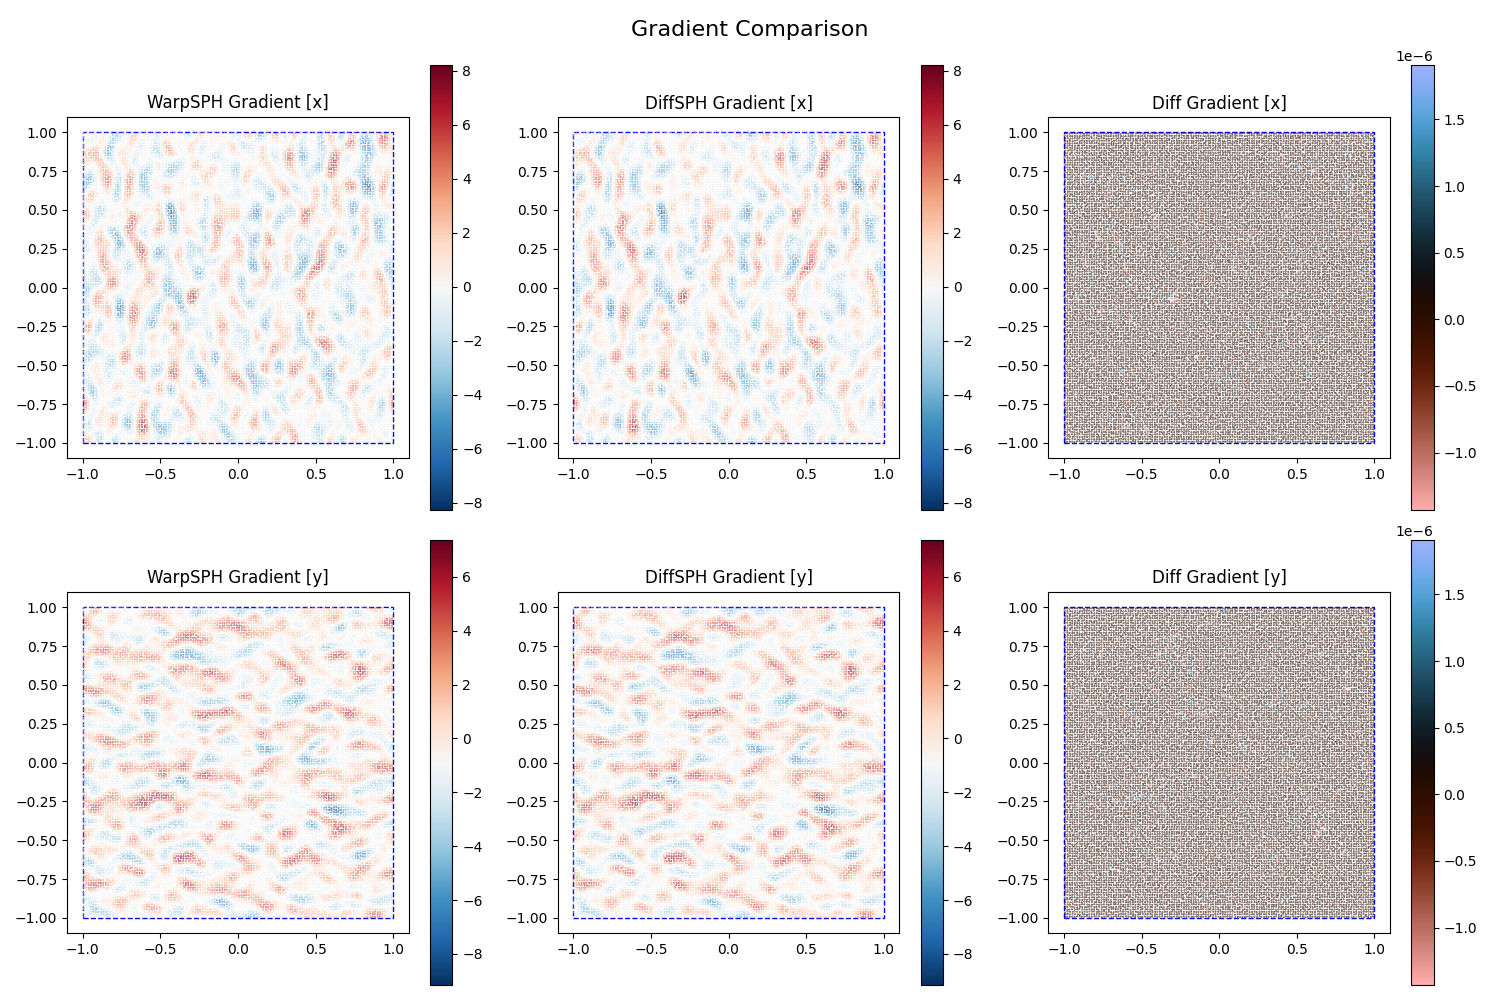

In [7]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = 0.1,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# We can also provide the vector quantity directly and set the mapping to extract the component internally.
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [x]", mapping = Mapping.x);
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [y]", mapping = Mapping.y);

if not warpOnly:    
    visualizeParticlesNew(fig, axis[0,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "DiffSPH Gradient [x]", mapping = Mapping.x);
    visualizeParticlesNew(fig, axis[1,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "DiffSPH Gradient [y]", mapping = Mapping.y);

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    visualizeParticlesNew(fig, axis[0,2], particleState, quantity = diff_x, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [x]", colorMap = ColorMap.berlin);
    visualizeParticlesNew(fig, axis[1,2], particleState, quantity = diff_y, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [y]", colorMap = ColorMap.berlin);


fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()

fig.savefig("output/smoothedGradient_comparison.png", dpi=300)


In [8]:
from warpSPHPlotting import *

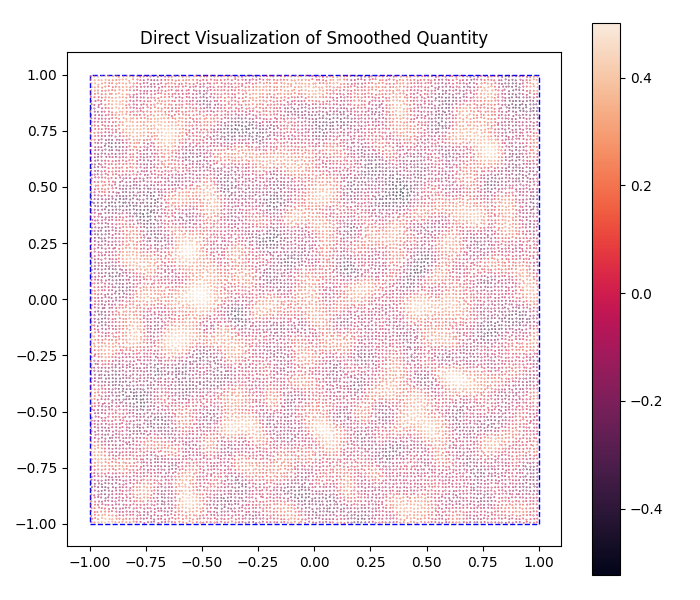

In [9]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# Here we visualize the quantity directly as a scatter plot of the particle quantities
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 0.1,
        midPoint = 'median',
        plotTitle = "Direct Visualization of Smoothed Quantity",
    ),
    verbose = False,
)

fig.tight_layout()
# fig.savefig("output/smoothedQuantity_visualization.png", dpi=300)

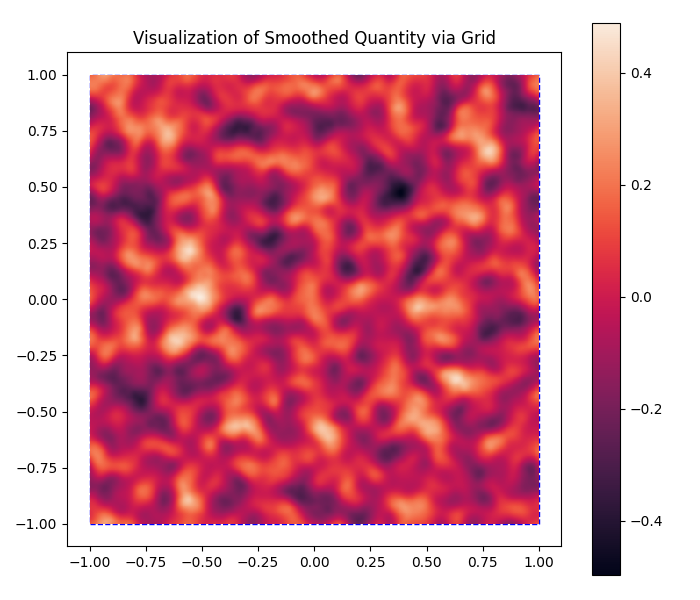

In [10]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# Here we visualize the quantity directly as a scatter plot of the particle quantities
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 0.1,
        midPoint = 'median',
        plotTitle = "Visualization of Smoothed Quantity via Grid",
        gridVisualization = GridVisualization(
            resolution = 512,
        ),
    ),
    verbose = False,
)


fig.tight_layout()
fig.savefig("output/smoothedQuantity_visualization_Grid.png", dpi=300)

In [11]:
# Example of updating the plot with new data (e.g., after a simulation step)
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = -f_smoothed,
    colorMap = ColorMap.viridis,
)
fig.savefig("output/smoothedQuantity_visualization_Grid_updated.png", dpi=300)

Module warpSPHCore.operations_grid.wp_gradient_grid 1438654 load on device 'cpu' took 2105.15 ms  (compiled)


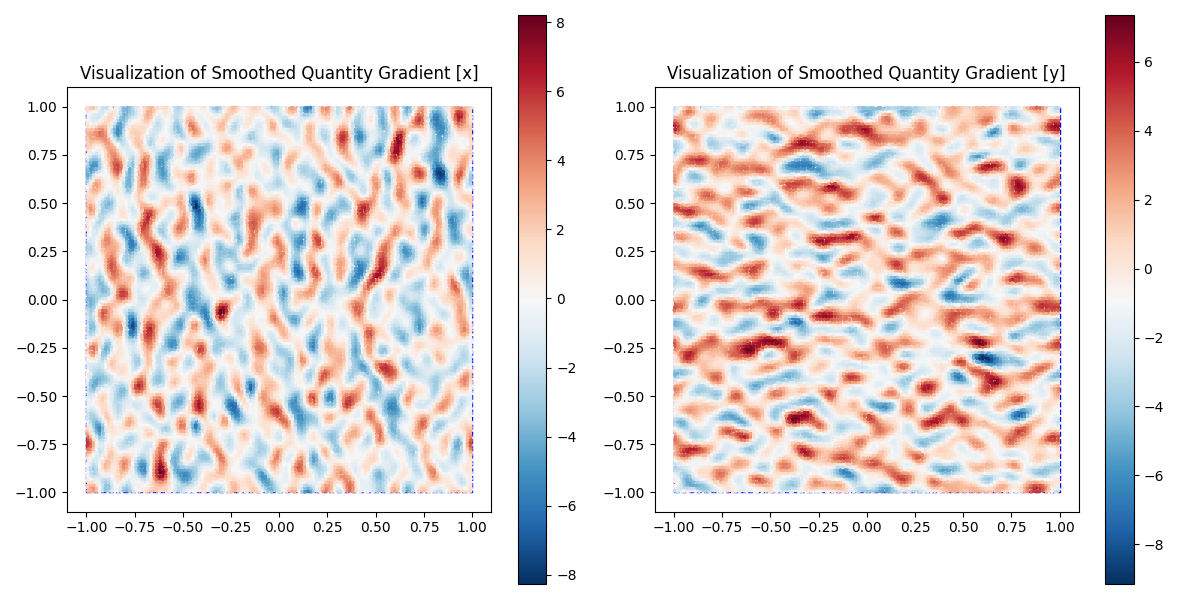

In [12]:
fig, axis = plt.subplots(1,2, figsize=(12,6), squeeze=False)

# Here we visualize the gradient of the smoothed quantity by computing the gradient within the plotting function instead of supplying it explicitly. This allows us to see how the plotting function handles the gradient computation and visualization in one step, which can be useful for debugging and understanding the behavior of the gradient field without needing to compute it separately beforehand.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.x,
        plotTitle = "Visualization of Smoothed Quantity Gradient [x]"
    ),
    verbose = False,
)

newState = visualizeParticlesNew(
    fig, axis[0,1],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.y,
        plotTitle = "Visualization of Smoothed Quantity Gradient [y]"
    ),
    verbose = False,
)

fig.tight_layout()
fig.savefig("output/smoothedGradient_visualization.png", dpi=300)

Module warpSPHCore.operations_grid.wp_interpolate_grid f4ba0b9 load on device 'cpu' took 1707.06 ms  (compiled)


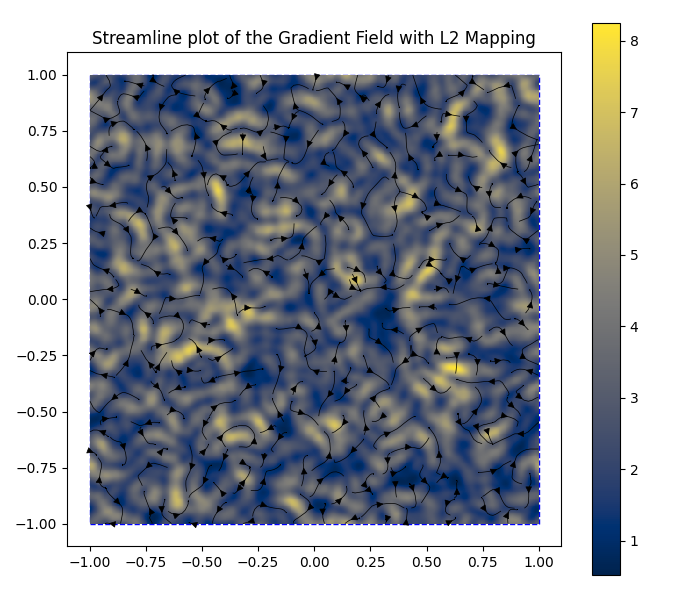

In [13]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# We can also directly visualize the gradient magnitude while plotting streamlines of the gradient field before mapping to see the raw gradient field structure without the influence of the mapping operation. This can be useful for debugging and understanding the behavior of the gradient field itself.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = gradient_warp,
    options = PlottingOptions(
        colorMap = ColorMap.cividis,
        showColorBar = True,
        markerSize = 2,
        midPoint = 'median',
        quantityScaling = PlotScaling.Linear,
        mapping = Mapping.L2,
        plottingOperation = None,
        gridVisualization = GridVisualization(
            resolution = 512,
            streamLines = True,
            streamLineOperationLocation=StreamLineLocation.BeforeMapping,
            streamLineOperation=None
        ),
        plotTitle = "Streamline plot of the Gradient Field with L2 Mapping"
    ),
    verbose = False,
)

fig.tight_layout()
fig.savefig("output/gradientStreamlines_beforeMapping.png", dpi=300)

In [14]:
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = gradient_warp,
    colorMap = ColorMap.viridis,
)
fig.savefig("output/gradientStreamlines_beforeMapping_updated.png", dpi=300)